# B. Матрицы и забытые активации

Так как в сети нет нелинейностей и сдвигов, отображение $T(x_1,x_2)$ линейно.  
Известны два значения:

$$
T(-2,3)=\begin{pmatrix}60\\40\\100\end{pmatrix},\qquad
T(1,3)=\begin{pmatrix}200\\50\\80\end{pmatrix}
$$

так как эти числа не выходят за пределы $[0,255]$, обрезание ничего не меняет.

Нужно найти $T(-7,6)$. Заметим, что

$$
(-7,6)=3\cdot(-2,3)-1\cdot(1,3).
$$

Тогда

$$
T(-7,6)=3T(-2,3)-T(1,3)
=
3\begin{pmatrix}60\\40\\100\end{pmatrix}
-
\begin{pmatrix}200\\50\\80\end{pmatrix}
=
\begin{pmatrix}-20\\70\\220\end{pmatrix}.
$$

После обрезания получаем:

$$
f(-7,6)=\begin{pmatrix}0\\70\\220\end{pmatrix}.
$$

Ответ: `0 70 220`

---

# C. Среднее и медиана

Упорядочим точки $x_{(1)}\le\dots\le x_{(10)}$.  
Обозначим $d_i=x_{(i+1)}-x_{(i)}$, $i=1,\dots,9$.

Условия дают:

$$
0.01\le d_i\le 0.25,\qquad
x_{(1)}\le 0.25,\qquad
x_{(10)}\ge 0.75.
$$

Разность среднего и медианы равна:

$$
\bar x-m=
-0.1d_1-0.2d_2-0.3d_3-0.4d_4+0\cdot d_5
+0.4d_6+0.3d_7+0.2d_8+0.1d_9.
$$

Чтобы максимизировать эту величину, нужно:

- $d_1,d_2,d_3,d_4$ взять минимальными: $0.01$;
- $d_5$ не влияет, берём $0.01$;
- оставшуюся длину распределить по $d_6,d_7,d_8,d_9$ в порядке убывания коэффициентов.

Сумма всех промежутков равна $1$. Тогда:

$$
d_6=0.25,\quad d_7=0.25,\quad d_8=0.25,\quad d_9=0.20.
$$

Отсюда

$$
\bar x-m=0.235.
$$

По симметрии максимальное абсолютное отклонение такое же.

Ответ: `0.235000`

# F. NLP

Среднее: 14.3607


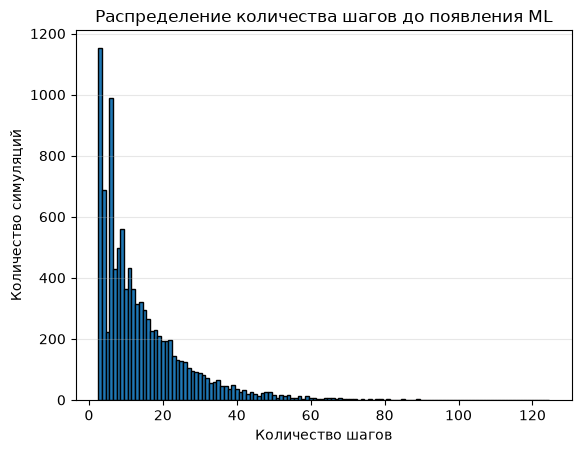

In [2]:
import numpy as np
import matplotlib.pyplot as plt

next = {
    'A': ['M', 'D'],
    'E': ['T', 'S', 'M'],
    'I': ['T', 'S', 'M'],
    'T': ['L', 'N'],
    'M': ['L', 'N'],
    'N': ['A', 'I'],
    'D': ['A', 'I'],
    'S': ['E', 'I', 'D'],
    'L': ['E', 'I', 'D']
}

def simulate():
    last = 'S'
    steps = 0

    while True:
        new = np.random.choice(next[last])
        steps += 1

        if last == 'M' and new == 'L':
            return steps

        last = new

a = np.array([simulate() for _ in range(10000)])

print('Среднее:', np.mean(a))

plt.hist(a, bins=np.arange(a.min(), a.max() + 2) - 0.5, edgecolor='black')
plt.xlabel('Количество шагов')
plt.ylabel('Количество симуляций')
plt.title('Распределение количества шагов до появления ML')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
import numpy as np
import pandas as pd


items = pd.read_csv(
    "items_A.csv",
    dtype={
        "item_id": np.int64,
        "category": str,
        "price": np.int64,
        "rating": np.float64,
        "brand": str,
        "in_stock": np.int8
    }
)

edges = pd.read_csv(
    "also_viewed_A.csv",
    dtype={
        "item_from": np.int64,
        "item_to": np.int64
    }
)


item_ids = items["item_id"].to_numpy()
categories = items["category"].to_numpy()
price = items["price"].to_numpy()
rating = items["rating"].to_numpy()
stock = items["in_stock"].to_numpy()
brands_all = items["brand"].to_numpy()


# A1
a1 = np.count_nonzero(
    (categories == "phones") &
    (rating >= 4.5) &
    (stock == 1)
)

print("A1:", a1)


# A2
mask = categories == "laptops"

brands, inv = np.unique(brands_all[mask], return_inverse=True)
prices = price[mask]

sum_price = np.bincount(inv, weights=prices)
cnt_price = np.bincount(inv)

avg_price = sum_price / cnt_price

a2 = brands[np.argmax(avg_price)]

print("A2:", a2)


# A3
premium = (rating >= 4.5) & (price >= 50000)

a3 = np.count_nonzero(
    premium & (stock == 1)
)

print("A3:", a3)


order = np.argsort(item_ids)
sorted_ids = item_ids[order]


# A4
to_ids = np.unique(edges["item_to"].to_numpy())

pos = np.searchsorted(sorted_ids, to_ids)
item_indices = order[pos]

to_categories = categories[item_indices]

all_categories = np.sort(np.unique(categories))

cat_idx = np.searchsorted(all_categories, to_categories)

cnt = np.bincount(
    cat_idx,
    minlength=len(all_categories)
)

answer4 = pd.DataFrame({
    "category": all_categories,
    "cnt": cnt
})

answer4.to_csv(
    "answer4.csv",
    index=False
)

print("A4:")
print(answer4)


# A5
n = len(items)

parent = np.arange(n, dtype=np.int64)
size = np.ones(n, dtype=np.int64)


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(a, b):
    a = find(a)
    b = find(b)

    if a == b:
        return

    if size[a] < size[b]:
        a, b = b, a

    parent[b] = a
    size[a] += size[b]


edge_from = edges["item_from"].to_numpy()
edge_to = edges["item_to"].to_numpy()

u = order[np.searchsorted(sorted_ids, edge_from)]
v = order[np.searchsorted(sorted_ids, edge_to)]

for a, b in zip(u, v):
    union(a, b)


roots = np.empty(n, dtype=np.int64)

for i in range(n):
    roots[i] = find(i)


phones_roots = np.unique(
    roots[categories == "phones"]
)

accessories_roots = np.unique(
    roots[categories == "accessories"]
)

a5 = np.intersect1d(
    phones_roots,
    accessories_roots
).size

print("A5:", a5)

A1: 22
A2: Gamma
A3: 25
A4:
      category  cnt
0  accessories   53
1        books   14
2         home   13
3      laptops   16
4       phones   89
5         toys   12
A5: 11
